In [1]:
# ===============================================================================
# ResNet-50 with CBAM Multi-Level Fusion - STABLE VERSION
# Fixed training issues with standard loss function
# ===============================================================================

# Cell 1: Imports and Setup
import numpy as np
import pandas as pd
import os
import glob
import tensorflow as tf
from keras.preprocessing.image import ImageDataGenerator
from keras.applications import ResNet50
from keras.layers import (Dense, GlobalAveragePooling2D, Input, BatchNormalization, 
                         Conv2D, Multiply, Lambda, Concatenate, Dropout, 
                         Add, Activation, Reshape)
from keras.models import Model
from keras.optimizers import Adam
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from keras import backend as K
from keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.metrics import roc_curve, auc, roc_auc_score, hamming_loss, jaccard_score
import warnings
warnings.filterwarnings('ignore')

# Enable mixed precision for GTX 1060
tf.keras.mixed_precision.set_global_policy('mixed_float16')

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))
print("Mixed precision enabled for GTX 1060 optimization")

INFO:tensorflow:Mixed precision compatibility check (mixed_float16): OK
Your GPU will likely run quickly with dtype policy mixed_float16 as it has compute capability of at least 7.0. Your GPU: NVIDIA GeForce RTX 4050 Laptop GPU, compute capability 8.9
TensorFlow version: 2.10.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Mixed precision enabled for GTX 1060 optimization


In [3]:
# Cell 2: Dataset Configuration
BASE_DIR = "./dataset_balanced/"
CSV_PATH = os.path.join(BASE_DIR, "new_labels.csv")
IMAGE_DIR = os.path.join(BASE_DIR, "new_images")
IMAGE_FILES = {os.path.basename(f): f for f in glob.glob(os.path.join(IMAGE_DIR, "*.png"))}

print(f"Total images found: {len(IMAGE_FILES)}")

# Disease labels
labels = ['Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Effusion',
          'Emphysema', 'Fibrosis', 'Hernia', 'Infiltration', 'Mass',
          'Nodule', 'Pleural_Thickening', 'Pneumonia', 'Pneumothorax']

print(f"Disease classes: {len(labels)}")

Total images found: 51382
Disease classes: 14


In [4]:
# Cell 3: Data Loading and Balanced Split
df = pd.read_csv(CSV_PATH)
df = df[['Path'] + labels]

# Verify dataset balance
class_counts = df[labels].sum()
print("Class Distribution (confirming balance):")
print("=" * 50)
for label, count in zip(labels, class_counts):
    percentage = (count / len(df)) * 100
    print(f"{label:20s}: {count:5d} ({percentage:5.2f}%)")

# Since dataset is balanced, use simple stratification
df['has_any_disease'] = (df[labels].sum(axis=1) > 0).astype(int)

# Stratified split
train_df, val_df = train_test_split(
    df, 
    test_size=0.2, 
    random_state=42,
    stratify=df['has_any_disease']
)

print(f"\nDataset Split:")
print(f"Train: {len(train_df)} samples")
print(f"Validation: {len(val_df)} samples")

Class Distribution (confirming balance):
Atelectasis         :  4788 ( 9.32%)
Cardiomegaly        :  4629 ( 9.01%)
Consolidation       :  4481 ( 8.72%)
Edema               :  4554 ( 8.86%)
Effusion            :  5000 ( 9.73%)
Emphysema           :  4467 ( 8.69%)
Fibrosis            :  5039 ( 9.81%)
Hernia              :  5590 (10.88%)
Infiltration        :  5740 (11.17%)
Mass                :  5564 (10.83%)
Nodule              :  5634 (10.96%)
Pleural_Thickening  :  4831 ( 9.40%)
Pneumonia           :  6105 (11.88%)
Pneumothorax        :  4919 ( 9.57%)

Dataset Split:
Train: 41105 samples
Validation: 10277 samples


In [5]:
# Cell 4: Conservative Data Generators
# Minimal augmentation for stability
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=5,            # Very conservative
    width_shift_range=0.05,      # Minimal
    height_shift_range=0.05,
    horizontal_flip=False,       # Never for chest X-rays
    zoom_range=0.02,            # Very subtle
    brightness_range=[0.95, 1.05], # Minimal brightness
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(rescale=1./255)

# Add paths and remove missing files
train_df['path'] = train_df['Path'].map(IMAGE_FILES)
val_df['path'] = val_df['Path'].map(IMAGE_FILES)
train_df = train_df.dropna(subset=['path'])
val_df = val_df.dropna(subset=['path'])

# Conservative batch size for GTX 1060
BATCH_SIZE = 6  # Reduced for stability

train_gen = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    directory=None,
    x_col='path',
    y_col=labels,
    target_size=(224, 224),
    batch_size=BATCH_SIZE,
    class_mode='raw',
    shuffle=True,
    seed=42
)

val_gen = val_datagen.flow_from_dataframe(
    dataframe=val_df,
    directory=None,
    x_col='path',
    y_col=labels,
    target_size=(224, 224),
    batch_size=BATCH_SIZE,
    class_mode='raw',
    shuffle=False,
    seed=42
)

print(f"Training batches: {len(train_gen)}")
print(f"Validation batches: {len(val_gen)}")

Found 41105 validated image filenames.
Found 10277 validated image filenames.
Training batches: 6851
Validation batches: 1713


In [6]:
# Cell 5: Stable CBAM Implementation
def channel_attention(input_feature, ratio=16, name_prefix=""):
    """Stable Channel Attention Module"""
    channel = input_feature.shape[-1]
    
    # Shared dense layers
    shared_dense_one = Dense(channel // ratio, activation='relu', name=f'{name_prefix}_ca_dense1')
    shared_dense_two = Dense(channel, name=f'{name_prefix}_ca_dense2')
    
    # Average pooling branch
    avg_pool = GlobalAveragePooling2D(name=f'{name_prefix}_ca_avg')(input_feature)
    avg_pool = Reshape((1, 1, channel))(avg_pool)
    avg_pool = shared_dense_one(avg_pool)
    avg_pool = shared_dense_two(avg_pool)
    
    # Max pooling branch  
    max_pool = Lambda(lambda x: K.max(x, axis=[1,2], keepdims=True), 
                     name=f'{name_prefix}_ca_max')(input_feature)
    max_pool = shared_dense_one(max_pool)
    max_pool = shared_dense_two(max_pool)
    
    # Combine and apply
    channel_att = Add(name=f'{name_prefix}_ca_add')([avg_pool, max_pool])
    channel_att = Activation('sigmoid', name=f'{name_prefix}_ca_sigmoid')(channel_att)
    
    return Multiply(name=f'{name_prefix}_ca_out')([input_feature, channel_att])

def spatial_attention(input_feature, name_prefix=""):
    """Stable Spatial Attention Module"""
    # Channel pooling
    avg_pool = Lambda(lambda x: K.mean(x, axis=-1, keepdims=True), 
                     name=f'{name_prefix}_sa_avg')(input_feature)
    max_pool = Lambda(lambda x: K.max(x, axis=-1, keepdims=True),
                     name=f'{name_prefix}_sa_max')(input_feature)
    
    # Concatenate and convolve
    concat = Concatenate(axis=-1, name=f'{name_prefix}_sa_concat')([avg_pool, max_pool])
    spatial_att = Conv2D(1, kernel_size=7, padding='same', activation='sigmoid',
                        kernel_initializer='he_normal', use_bias=False,
                        name=f'{name_prefix}_sa_conv')(concat)
    
    return Multiply(name=f'{name_prefix}_sa_out')([input_feature, spatial_att])

def cbam_block(input_feature, ratio=16, name_prefix="cbam"):
    """Complete CBAM: Channel + Spatial Attention"""
    x = channel_attention(input_feature, ratio, f"{name_prefix}_ch")
    x = spatial_attention(x, f"{name_prefix}_sp")
    return x

print("CBAM modules defined")

CBAM modules defined


In [7]:
# Cell 6: Simplified Stable Model Architecture
def create_stable_resnet_cbam_model(
    input_shape=(224, 224, 3),
    num_classes=14,
    trainable_layers=20  # Conservative number
):
    """
    Stable ResNet-50 + CBAM model
    Simplified to avoid training instability
    """
    
    inputs = Input(shape=input_shape, name='input')
    
    # ResNet-50 backbone
    resnet_base = ResNet50(weights='imagenet', include_top=False, input_shape=input_shape)
    
    # Conservative layer unfreezing
    for i, layer in enumerate(resnet_base.layers):
        if i < len(resnet_base.layers) - trainable_layers:
            layer.trainable = False
        else:
            layer.trainable = True
    
    # Extract features at two levels only (for stability)
    intermediate_layer = resnet_base.get_layer('conv4_block6_out')
    
    # Create feature extractor
    feature_extractor = Model(
        inputs=resnet_base.input,
        outputs=[
            intermediate_layer.output,  # High-level: 14x14x1024
            resnet_base.output         # Top-level: 7x7x2048
        ],
        name='feature_extractor'
    )
    
    high_features, top_features = feature_extractor(inputs)
    
    # Apply CBAM with conservative ratios
    high_cbam = cbam_block(high_features, ratio=8, name_prefix="high")
    top_cbam = cbam_block(top_features, ratio=8, name_prefix="top")
    
    # Simple feature fusion
    high_pooled = GlobalAveragePooling2D(name='high_gap')(high_cbam)
    top_pooled = GlobalAveragePooling2D(name='top_gap')(top_cbam)
    
    # Project to same dimensions
    high_proj = Dense(512, activation='relu', name='high_proj')(high_pooled)
    high_proj = BatchNormalization(name='high_bn')(high_proj)
    high_proj = Dropout(0.3, name='high_drop')(high_proj)
    
    top_proj = Dense(512, activation='relu', name='top_proj')(top_pooled)
    top_proj = BatchNormalization(name='top_bn')(top_proj)
    top_proj = Dropout(0.3, name='top_drop')(top_proj)
    
    # Fuse features
    fused = Add(name='fusion')([high_proj, top_proj])
    
    # Simple classification head
    x = Dense(256, activation='relu', name='cls1')(fused)
    x = BatchNormalization(name='cls_bn1')(x)
    x = Dropout(0.4, name='cls_drop1')(x)
    
    x = Dense(128, activation='relu', name='cls2')(x)
    x = BatchNormalization(name='cls_bn2')(x)
    x = Dropout(0.3, name='cls_drop2')(x)
    
    # Output layer (float32 for mixed precision)
    outputs = Dense(num_classes, activation='sigmoid', dtype='float32', name='output')(x)
    
    model = Model(inputs=inputs, outputs=outputs, name='Stable_ResNet_CBAM')
    return model, resnet_base

print("Model architecture function defined")

Model architecture function defined


In [8]:
# Cell 7: Model Creation with Conservative Settings
print("Creating stable ResNet-50 + CBAM model...")

model, backbone = create_stable_resnet_cbam_model(
    input_shape=(224, 224, 3),
    num_classes=len(labels),
    trainable_layers=20
)

print(f"Model created successfully")
print(f"Total parameters: {model.count_params():,}")
print(f"Trainable parameters: {sum([K.count_params(w) for w in model.trainable_weights]):,}")

# Memory check
total_params = model.count_params()
estimated_memory = (total_params * 4 * 3) / (1024**3)
print(f"Estimated VRAM usage: {estimated_memory:.1f}GB")

if estimated_memory < 5.0:
    print("Memory usage is safe for GTX 1060")
else:
    print("Consider reducing batch size if memory issues occur")

Creating stable ResNet-50 + CBAM model...
94765736/94765736 [==============================] - 18s 0us/step
Model created successfully
Total parameters: 26,647,634
Trainable parameters: 11,988,434
Estimated VRAM usage: 0.3GB
Memory usage is safe for GTX 1060


In [9]:
# Cell 8: Model Compilation with Standard Loss
# Use standard binary crossentropy - no custom loss needed for balanced dataset
model.compile(
    optimizer=Adam(
        learning_rate=5e-5,     # Conservative learning rate
        beta_1=0.9,
        beta_2=0.999,
        epsilon=1e-8
    ),
    loss='binary_crossentropy',  # Standard loss for balanced data
    metrics=[
        'binary_accuracy',
        tf.keras.metrics.AUC(name='auc', multi_label=True),
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)

print("Model compiled with standard binary crossentropy loss")
print(f"Learning rate: {model.optimizer.learning_rate.numpy()}")

# Test model stability
print("\nTesting model with dummy input...")
dummy_input = tf.random.normal((2, 224, 224, 3))
dummy_output = model(dummy_input)
print(f"Input shape: {dummy_input.shape}")
print(f"Output shape: {dummy_output.shape}")
print(f"Output range: [{dummy_output.numpy().min():.3f}, {dummy_output.numpy().max():.3f}]")
print("Model test passed")

Model compiled with standard binary crossentropy loss
Learning rate: 4.999999873689376e-05

Testing model with dummy input...
Input shape: (2, 224, 224, 3)
Output shape: (2, 14)
Output range: [0.351, 0.617]
Model test passed


In [10]:
# Cell 9: Conservative Training Setup
# Create output directory
os.makedirs('./output', exist_ok=True)

# Conservative callbacks for stable training
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=8,
        mode='min',
        restore_best_weights=True,
        verbose=1,
        min_delta=0.001
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=4,
        min_lr=1e-7,
        mode='min',
        verbose=1,
        min_delta=0.001
    ),
    ModelCheckpoint(
        './output/stable_resnet_cbam_best.keras',
        monitor='val_loss',
        save_best_only=True,
        mode='min',
        verbose=1
    )
]

# Training configuration
EPOCHS = 25
print(f"Training setup:")
print(f"- Epochs: {EPOCHS}")
print(f"- Batch size: {BATCH_SIZE}")
print(f"- Learning rate: {model.optimizer.learning_rate.numpy()}")
print(f"- Loss function: binary_crossentropy")
print(f"- Early stopping patience: 8")

Training setup:
- Epochs: 25
- Batch size: 6
- Learning rate: 4.999999873689376e-05
- Loss function: binary_crossentropy
- Early stopping patience: 8


In [11]:
# Cell 10: Stable Model Training
print("Starting stable training...")
print("=" * 60)

try:
    history = model.fit(
        train_gen,
        epochs=EPOCHS,
        validation_data=val_gen,
        callbacks=callbacks,
        verbose=1,
        workers=2,
        use_multiprocessing=False
    )
    
    print("Training completed successfully!")
    
    # Save final model
    model.save('./output/stable_resnet_cbam_final.keras')
    print("Final model saved")
    
except Exception as e:
    print(f"Training error: {e}")
    # Save current state
    model.save('./output/stable_resnet_cbam_interrupted.keras')

Starting stable training...
Epoch 1/25
6851/6851 [==============================] - ETA: 0s - loss: 0.5757 - binary_accuracy: 0.7206 - auc: 0.5298 - precision: 0.1127 - recall: 0.2649
Epoch 1: val_loss improved from inf to 0.32857, saving model to ./output\stable_resnet_cbam_best.keras
6851/6851 [==============================] - 820s 118ms/step - loss: 0.5757 - binary_accuracy: 0.7206 - auc: 0.5298 - precision: 0.1127 - recall: 0.2649 - val_loss: 0.3286 - val_binary_accuracy: 0.8999 - val_auc: 0.5968 - val_precision: 0.4650 - val_recall: 0.0245 - lr: 5.0000e-05
Epoch 2/25
6851/6851 [==============================] - ETA: 0s - loss: 0.3423 - binary_accuracy: 0.8956 - auc: 0.5682 - precision: 0.2351 - recall: 0.0240
Epoch 2: val_loss improved from 0.32857 to 0.31149, saving model to ./output\stable_resnet_cbam_best.keras
6851/6851 [==============================] - 753s 110ms/step - loss: 0.3423 - binary_accuracy: 0.8956 - auc: 0.5682 - precision: 0.2351 - recall: 0.0240 - val_loss: 0.3

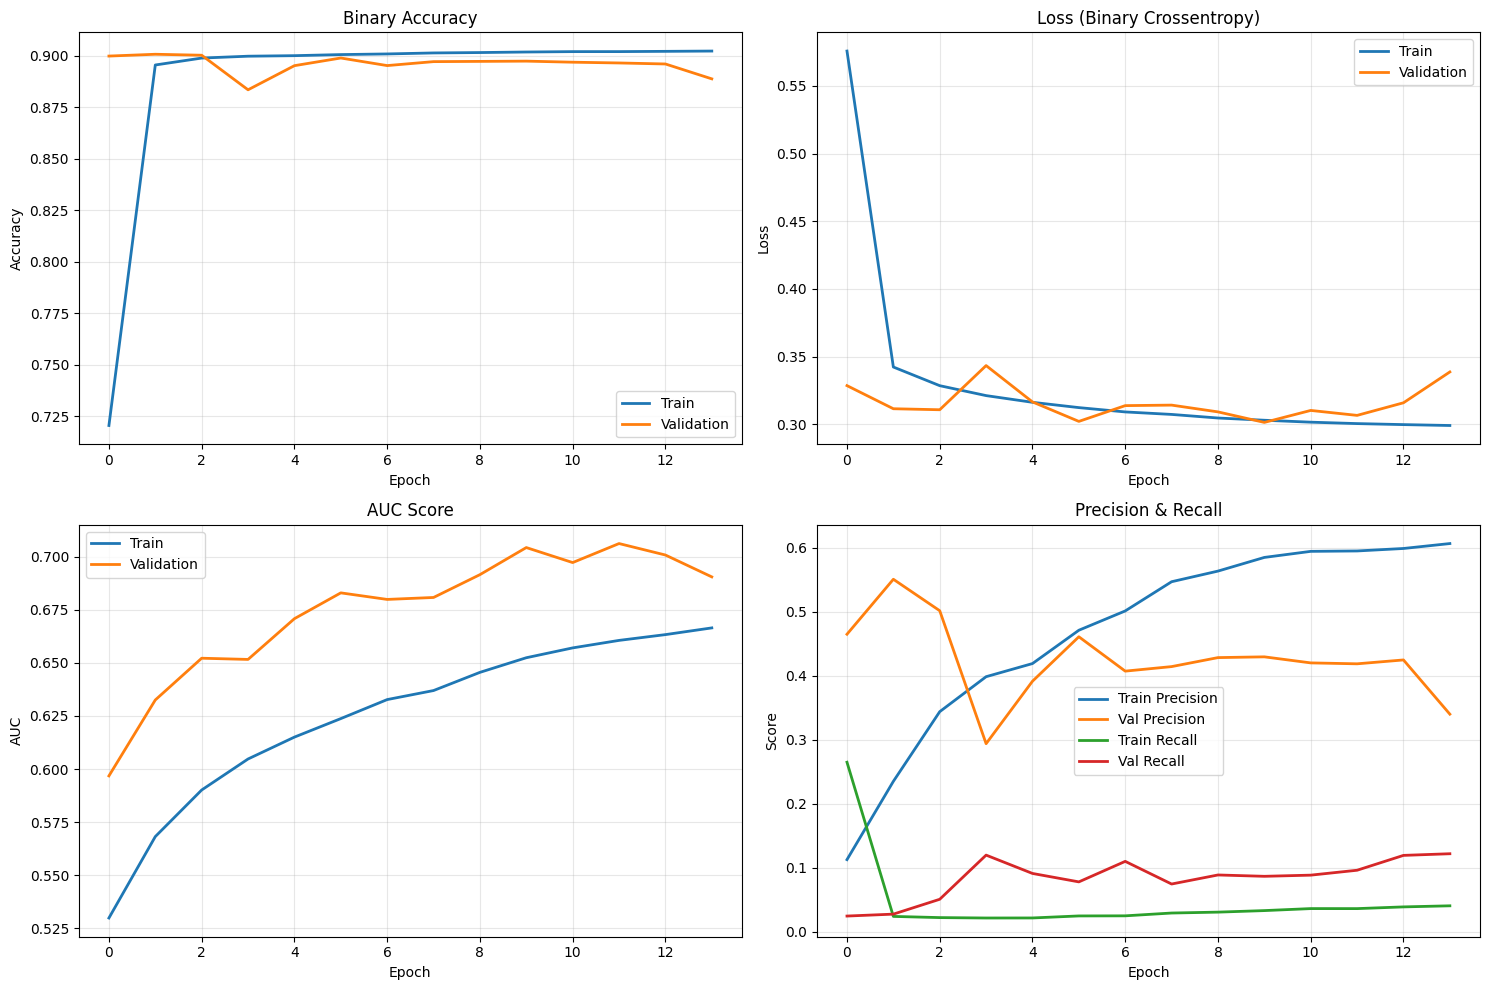


Final Training Metrics (Epoch 14):
Training Loss: 0.2991
Validation Loss: 0.3387
Training Accuracy: 0.9024
Validation Accuracy: 0.8889
Validation AUC: 0.6905


In [12]:
# Cell 11: Training Visualization - Clean Plots
def plot_stable_training_history(history):
    """Plot clean training history"""
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))
    
    # Accuracy
    ax1.plot(history.history['binary_accuracy'], label='Train', linewidth=2)
    ax1.plot(history.history['val_binary_accuracy'], label='Validation', linewidth=2)
    ax1.set_title('Binary Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Loss  
    ax2.plot(history.history['loss'], label='Train', linewidth=2)
    ax2.plot(history.history['val_loss'], label='Validation', linewidth=2)
    ax2.set_title('Loss (Binary Crossentropy)')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # AUC
    ax3.plot(history.history['auc'], label='Train', linewidth=2)
    ax3.plot(history.history['val_auc'], label='Validation', linewidth=2)
    ax3.set_title('AUC Score')
    ax3.set_xlabel('Epoch')
    ax3.set_ylabel('AUC')
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    
    # Precision & Recall
    ax4.plot(history.history['precision'], label='Train Precision', linewidth=2)
    ax4.plot(history.history['val_precision'], label='Val Precision', linewidth=2)
    ax4.plot(history.history['recall'], label='Train Recall', linewidth=2)
    ax4.plot(history.history['val_recall'], label='Val Recall', linewidth=2)
    ax4.set_title('Precision & Recall')
    ax4.set_xlabel('Epoch')
    ax4.set_ylabel('Score')
    ax4.legend()
    ax4.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('./output/stable_training_history.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Print final metrics
    final_epoch = len(history.history['loss']) - 1
    print(f"\nFinal Training Metrics (Epoch {final_epoch + 1}):")
    print(f"Training Loss: {history.history['loss'][final_epoch]:.4f}")
    print(f"Validation Loss: {history.history['val_loss'][final_epoch]:.4f}")
    print(f"Training Accuracy: {history.history['binary_accuracy'][final_epoch]:.4f}")
    print(f"Validation Accuracy: {history.history['val_binary_accuracy'][final_epoch]:.4f}")
    print(f"Validation AUC: {history.history['val_auc'][final_epoch]:.4f}")

if 'history' in locals():
    plot_stable_training_history(history)

In [13]:
# Cell 12: Model Evaluation
def evaluate_stable_model():
    """Evaluate the stable model"""
    print("Loading best model...")
    
    best_model = tf.keras.models.load_model('./output/stable_resnet_cbam_best.keras')
    
    print("Generating predictions...")
    val_gen.reset()
    y_pred = best_model.predict(val_gen, verbose=1)
    
    # Get true labels
    y_true = []
    val_gen.reset()
    for i in range(len(val_gen)):
        _, batch_y = val_gen[i]
        y_true.extend(batch_y)
        if i >= len(val_gen) - 1:
            break
    
    y_true = np.array(y_true)
    
    print(f"Evaluation on {len(y_true)} samples")
    
    # Per-class AUC
    print("\nPer-Class AUC Scores:")
    print("-" * 40)
    
    individual_aucs = []
    for i, label in enumerate(labels):
        if np.sum(y_true[:, i]) > 0:
            auc_score = roc_auc_score(y_true[:, i], y_pred[:, i])
            individual_aucs.append(auc_score)
            print(f"{label:20s}: {auc_score:.4f}")
    
    mean_auc = np.mean(individual_aucs)
    print(f"\nMean AUC: {mean_auc:.4f}")
    
    # Multi-label metrics
    y_pred_binary = (y_pred > 0.5).astype(int)
    hamming = hamming_loss(y_true, y_pred_binary)
    jaccard = jaccard_score(y_true, y_pred_binary, average='samples')
    
    print(f"Hamming Loss: {hamming:.4f}")
    print(f"Jaccard Score: {jaccard:.4f}")
    
    return y_true, y_pred, mean_auc

if os.path.exists('./output/stable_resnet_cbam_best.keras'):
    y_true, y_pred, mean_auc = evaluate_stable_model()
    print("Evaluation completed")

Loading best model...
Generating predictions...
1713/1713 [==============================] - 166s 97ms/step
Evaluation on 10277 samples

Per-Class AUC Scores:
----------------------------------------
Atelectasis         : 0.6072
Cardiomegaly        : 0.6883
Consolidation       : 0.6850
Edema               : 0.8624
Effusion            : 0.6661
Emphysema           : 0.6639
Fibrosis            : 0.7661
Hernia              : 0.9032
Infiltration        : 0.6118
Mass                : 0.6197
Nodule              : 0.6704
Pleural_Thickening  : 0.6249
Pneumonia           : 0.8438
Pneumothorax        : 0.6516

Mean AUC: 0.7046
Hamming Loss: 0.1025
Jaccard Score: 0.0393
Evaluation completed


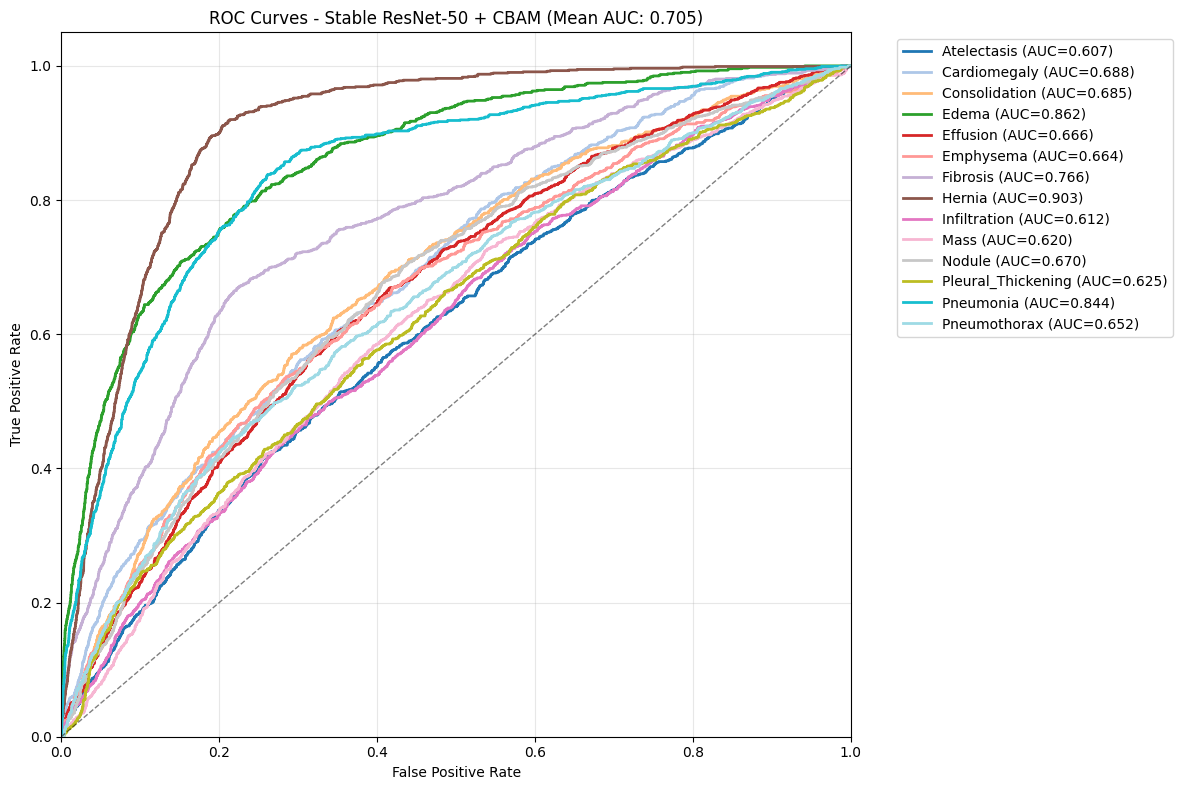

Results saved - Mean AUC: 0.7046


: 

In [ ]:
# Cell 13: Results Visualization and Saving
def plot_results_and_save(y_true, y_pred):
    """Plot ROC curves and save results"""
    plt.figure(figsize=(12, 8))
    
    aucs = []
    colors = plt.cm.tab20(np.linspace(0, 1, len(labels)))
    
    for i, (label, color) in enumerate(zip(labels, colors)):
        if np.sum(y_true[:, i]) > 0:
            fpr, tpr, _ = roc_curve(y_true[:, i], y_pred[:, i])
            auc_score = auc(fpr, tpr)
            aucs.append(auc_score)
            
            plt.plot(fpr, tpr, color=color, linewidth=2,
                    label=f'{label} (AUC={auc_score:.3f})')
    
    plt.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curves - Stable ResNet-50 + CBAM (Mean AUC: {np.mean(aucs):.3f})')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('./output/stable_roc_curves.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Save detailed results
    results_df = pd.DataFrame({
        'Disease': labels[:len(aucs)],
        'AUC': aucs,
        'Positive_Samples': [np.sum(y_true[:, i]) for i in range(len(aucs))]
    })
    results_df['Mean_AUC'] = np.mean(aucs)
    results_df.to_csv('./output/stable_model_results.csv', index=False)
    
    print(f"Results saved - Mean AUC: {np.mean(aucs):.4f}")

if 'y_true' in locals():
    plot_results_and_save(y_true, y_pred)